NOM(s) et PRENOM(s) : Romain FAVRE-BULLE et Hugo CASSETTE

Groupe de TD : B2a

# INF TC1 - TD7bis - Rendu de monnaie

---

## Le problème de "rendu de monnaie"

Une machine doit rendre un montant à un client à partir de pièces.

On considère un montant *M*.

Un stock de pièces est un tuple $S=(v_1, v_2, ..., v_n)$ où $v_i$ est la valeur de la $i^{ème}$ pièce (dans l'ordre croissant).

Dans certaines situations, on a également une table de disponibilité *D*. Nous noterons *d[i]=k* pour dire : il y a *k* pièces du montant *$v_i$*.

On cherche un tuple $T=(x_1, x_2, ..., x_n)$ (qui contient le nombre de chaque pièce choisi) tel que $M = \sum_{i=1}^n x_i.v_i$, en minimisant la fonction : $Q(S,M) = \sum_{i=1}^n x_i$.

## 3. Algorithme de Programmation Dynamique

On veut un programme qui, pour un montant $M$ et un stock $S$, renvoie le nombre de pièces utilisées $Q$ (puis le tuple $T$ dans un second temps).

Pour cela, on va :
1) identifier une formule récursive, 
2) résoudre le problème pour les cas limites,
3) itérer pour résoudre le problème complet. 

Supposons que l'on puisse calculer $Q$ pour tout montant $M' < M$.

Si on choisit une pièce $v_i$, on a  $Q(M-v_i)$.

$Q(i,m) = min
\begin{cases}
  1 + Q(i, m - v_i) \quad si \ (m - v_i) \geq 0  \qquad \text{(dans le cas où la pièce vi marche)}\\
Q(i-1, m) \qquad \quad    si \ i \geq 1 \qquad \qquad \quad \text{(la pièce vi ne marche pas)}
\end{cases}$

L'inconvénient de cette méthode est que chaque appel à $Q_{opt}$ fait deux appels à lui-même, donc le nombre d'opérations nécessaires est exponentiel à la taille de *M*. Pour éviter cela nous ferons appel au principe de *mémoïsation* de la programmation dynamique, en stockant les résultats intermédiaires dans une matrice `mat[|S|][M]` (Figure 2).

<center>
<img src="monnaie-progdyn.png" alt="Image originale" style="height:5cm;">
</center>
<center>
    <i>Figure 2</i>
</center>

En colonne, la valeur de M. En ligne, les pièces auxquelles on a accès. La valeur du coefficient (i,j) est le nombre minimal de pièces à utiliser. Le remplissage de chaque cellule se fait en calculant le minimum de deux voisins. Si un voisin est hors de la matrice, il ne compte pas dans le calcul du minimum.

**Question 3.1 -** Proposer une solution Python de cette méthode. Dans une première étape, trouver simplement le nombre minimal de pièces. Renvoyer `None` si il n'existe pas de solution possible.

In [ ]:
def Progdyn(S, M):
    """
    Résout le problème du rendu de monnaie en utilisant la programmation dynamique.
    Args:
        S (list): Liste des pièces disponibles.
        M (int): Montant à atteindre.
    Returns:
        int: Nombre minimum de pièces nécessaires pour atteindre le montant M, ou None si ce n'est pas possible.
    """
    n = len(S)
    # Initialisation de la matrice d'indices
    mat = [[0 if m == 0 else float('inf') for m in range(M + 1)] for i in range(n + 1)]

    # Remplissage de la matrice d'indices
    for i in range(1, n + 1): # A chaque ligne de la matrice, on rajoute une pièce
        for m in range(1, M + 1): # A chaque colonne de la matrice, on regarde le montant à atteindre
            if m - S[i - 1] >= 0:
                mat[i][m] = min(1 + mat[i][m - S[i - 1]], mat[i - 1][m])
            else:
                mat[i][m] = mat[i - 1][m]

    return mat[n][M] if mat[n][M] != float('inf') else None

**Tests**

Pour les tests, pour plus d'efficacité, on a créé une fonction de test affichant le résultat obtenu, et une liste d'entrées contenant le système de monnaie utilisé et le montant à atteindre.

Résultats attendus :

- 900 = 500+200+200 donc 3 pièces
- 9 = 5+2+2 donc 3 pièces
- 3 impossible avec seulement des pièces de 2
- 6 = 3+3 donc 2 pièces
- montant nul donc 0 pièce

In [2]:
def test_Progdyn(pieces, montant):
    resultat = Progdyn(pieces, montant)
    if resultat is not None:
        print(f"Le nombre minimum de pièces nécessaires pour atteindre {montant} est: {resultat}")
    else:
        print(f"Il n'est pas possible d'atteindre {montant} avec les pièces disponibles.")
    
entrees = [
    ([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000], 900),
    ([1, 2, 5], 9),
    ([2], 3),
    ([1, 3, 4], 6),
    ([1, 2, 5], 0)
]

for i in range(len(entrees)):
    print(f"Test {i+1}:")
    test_Progdyn(entrees[i][0], entrees[i][1])

Test 1:
Le nombre minimum de pièces nécessaires pour atteindre 900 est: 3
Test 2:
Le nombre minimum de pièces nécessaires pour atteindre 9 est: 3
Test 3:
Il n'est pas possible d'atteindre 3 avec les pièces disponibles.
Test 4:
Le nombre minimum de pièces nécessaires pour atteindre 6 est: 2
Test 5:
Le nombre minimum de pièces nécessaires pour atteindre 0 est: 0


On a le nombre de pièces utilisées, mais pas le type de chaque pièce utilisée...

**Question 3.2 -** Modifier votre solution pour renvoyer également les pièces utilisées.

On reprend le même principe, mais on ajoute une matrice "used" et on décompose le min en 2 conditions if, pour modifier "used" en accord avec le choix fait.

In [3]:
def Progdyn2(S, M):
    """
    Résout le problème du rendu de monnaie en utilisant la programmation dynamique et retourne à la fois le nombre minimum de pièces nécessaires et la liste des pièces utilisées.
    Args:
        S (list): Liste des pièces disponibles.
        M (int): Montant à atteindre.
    Returns:
        tuple: (Nombre minimum de pièces nécessaires pour atteindre le montant M, Liste des pièces utilisées), ou (None, []) si ce n'est pas possible.
    """
    # Initialisation de la matrice d'indices et de la matrice de suivi des pièces utilisées
    mat = [[0 if m == 0 else float('inf') for m in range(M + 1)] for i in range(len(S) + 1)]
    used = [[[] for m in range(M + 1)] for i in range(len(S) + 1)]
    # À la case used[i][m], on stocke la liste des pièces utilisées pour atteindre le montant m avec les i premières pièces.

    # Remplissage de la matrice d'indices et de la matrice de suivi des pièces utilisées
    for i in range(1, len(S) + 1):
        for m in range(1, M + 1):
            if m - S[i - 1] >= 0: #On reprend le même système, mais on décompose le min en 2 cas possibles
                if 1 + mat[i][m - S[i - 1]] < mat[i - 1][m]:
                    mat[i][m] = 1 + mat[i][m - S[i - 1]]
                    used[i][m] = used[i][m - S[i - 1]] + [S[i - 1]]
                else:
                    mat[i][m] = mat[i - 1][m]
                    used[i][m] = used[i - 1][m]
            else:
                mat[i][m] = mat[i - 1][m]
                used[i][m] = used[i - 1][m]

    result = mat[len(S)][M]
    pieces_used = used[len(S)][M]
    return (result, pieces_used) if result != float('inf') else (None, [])

**Tests**

On a créé une deuxième fonction de test sur le modèle de la première. On reprend les mêmes entrées, ce qui nous permet de vérifier les résultats du nombre total de pièces utilisées avec la première fonction.

Résultats attendus :

- 900 = 500+200+200 donc 3 pièces, [200, 200, 500]
- 9 = 5+2+2 donc 3 pièces, [5, 2, 2]
- 3 impossible avec seulement des pièces de 2
- 6 = 3+3 donc 2 pièces, [3, 3]
- montant nul donc 0 pièce

In [4]:
def test_Progdyn2(pieces, montant):
    resultat, pieces_utilisees = Progdyn2(pieces, montant)
    if resultat is not None:
        print(f"Le nombre minimum de pièces nécessaires pour atteindre {montant} est: {resultat}")
        print(f"Les pièces utilisées sont: {pieces_utilisees}")
    else:
        print(f"Il n'est pas possible d'atteindre {montant} avec les pièces disponibles.")
    
entrees = [
    ([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000], 900),
    ([1, 2, 5], 9),
    ([2], 3),
    ([1, 3, 4], 6),
    ([1, 2, 5], 0)
]

for i in range(len(entrees)):
    print(f"Test {i+1}:")
    test_Progdyn2(entrees[i][0], entrees[i][1])

Test 1:
Le nombre minimum de pièces nécessaires pour atteindre 900 est: 3
Les pièces utilisées sont: [200, 200, 500]
Test 2:
Le nombre minimum de pièces nécessaires pour atteindre 9 est: 3
Les pièces utilisées sont: [2, 2, 5]
Test 3:
Il n'est pas possible d'atteindre 3 avec les pièces disponibles.
Test 4:
Le nombre minimum de pièces nécessaires pour atteindre 6 est: 2
Les pièces utilisées sont: [3, 3]
Test 5:
Le nombre minimum de pièces nécessaires pour atteindre 0 est: 0
Les pièces utilisées sont: []


Jusque là, le stock de pièces était considéré infini. On peut rajouter une difficulté en limitant le nombre de pièces disponibles, à partir d'une matrice de disponibilité D.

**Question 3.3 -** On souhaite à présent implémenter en Programmation Dynamique la limite du stock de pièces présentée pour les exercices 1.2 et 1.3. Pour ce faire on modifie la formule de $Q_{opt}$ donnée précédemment (valable ici uniquement pour $i\geq1$) :

$Q_{opt}(i,m) = min
\begin{cases}
Q_{opt}(i-1, m) \qquad \qquad \qquad \qquad \qquad \qquad \qquad \text{ on n'utilise aucune pièce de type i}\\
1 + Q_{opt}(i-1, m-v_i) \quad si\ d_i\geq1\ et\ (m-v_i) \geq 0  \qquad \text{ on utilise 1 pièce de type i}\\
2 + Q_{opt}(i-1, m-2v_i) \quad si\ d_i\geq2\ et\ (m-2v_i) \geq 0  \quad \text{ on utilise 2 pièces de type i}\\
3 + Q_{opt}(i-1, m-3v_i) \quad si\ d_i\geq3\ et\ (m-3v_i) \geq 0  \quad \text{ on utilise 3 pièces de type i}\\
...
\end{cases}
$

Implémentez la limite de pièces avec cette nouvelle formule pour l'algorithme en Programmation Dynamique. Notez ici qu'on ne va plus chercher les valeurs sur la même ligne dans la matrice, mais qu'on remonte _systématiquement_ d'une ligne, pour qu'après l'utilisation de $k$ pièces de valeur $v_i$, on ne puisse plus ajouter d'autres pièces de cette même valeur.

In [5]:
def Progdyn3(S, M, D):
    """
    Résout le problème du rendu de monnaie en utilisant la programmation dynamique 
    avec une contrainte de stock limité pour chaque type de pièce.
    
    Args:
        S (list): Liste des pièces disponibles.
        M (int): Montant à atteindre.
        D (list): Liste des quantités disponibles pour chaque type de pièce.
        
    Returns:
        tuple: (Nombre minimum de pièces nécessaires pour atteindre le montant M, 
                Liste des pièces utilisées), ou None si ce n'est pas possible.
    """
    # Initialisation de la matrice d'indices
    mat = [[0 if m == 0 else float('inf') for m in range(M + 1)] for i in range(len(S) + 1)]
    # Initialisation de la matrice de suivi des pièces utilisées
    used = [[[] for m in range(M + 1)] for i in range(len(S) + 1)]

    # Remplissage de la matrice d'indices et de la matrice de suivi
    for i in range(1, len(S) + 1):
        for m in range(1, M + 1):
            # Par défaut, on hérite du résultat de la ligne précédente (on utilise 0 pièce de type i)
            mat[i][m] = mat[i - 1][m]
            used[i][m] = used[i - 1][m]
            
            # On essaie d'utiliser k pièces de type i (de 1 jusqu'au maximum disponible dans le stock D)
            for k in range(1, D[i - 1] + 1):  
                if m - k * S[i - 1] >= 0:  # Vérifie que le montant restant est non négatif
                    
                    # On calcule le coût potentiel si on prend k pièces de type i
                    cout_potentiel = k + mat[i - 1][m - k * S[i - 1]]
                    
                    # Si ce choix est strictement meilleur que ce qu'on a trouvé avant
                    if cout_potentiel < mat[i][m]:
                        mat[i][m] = cout_potentiel
                        # On récupère les pièces utilisées pour le reste, et on ajoute k fois la pièce actuelle
                        used[i][m] = used[i - 1][m - k * S[i - 1]] + [S[i - 1]] * k

    result = mat[len(S)][M]
    pieces_used = used[len(S)][M]
    
    # Retourne le tuple (nombre, liste) ou None si impossible
    return (result, pieces_used) if result != float('inf') else None, []

**Tests**

On a créé une troisième fonction de test. On reprend les mêmes entrées, en ajoutant les disponibilités.

Résultats attendus :

- Stock illimité (D[i] très grand) : même résultat que progdyn
- Stock limité : S=[1,2,5], D=[0,2,1] donc max 2 pièces de 2c et 1 pièce de 5c
- Impossible : on ne peut pas rendre 3c avec seulement une pièce de 2c

In [6]:
def test_Progdyn3(pieces, montant, stock):
    resultat, pieces_utilisees = Progdyn3(pieces, montant, stock)
    if resultat is not None:
        print(f"Le nombre minimum de pièces nécessaires pour atteindre {montant} avec le stock {stock} est: {resultat}")
        print(f"Les pièces utilisées sont: {pieces_utilisees}")
    else:
        print(f"Il n'est pas possible d'atteindre {montant} avec les pièces disponibles et le stock {stock}.")
    
entrees = [
    ([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000], 900, [100] * 13),
    ([1, 2, 5], 9, [0, 2, 1]),
    ([2], 3, [1]),
    ([1, 3, 4], 6, [2, 1, 1]),
    ([1, 2, 5], 0, [0, 0, 0])
]

for i in range(len(entrees)):
    print(f"Test {i+1}:")
    test_Progdyn3(entrees[i][0], entrees[i][1], entrees[i][2])

Test 1:
Le nombre minimum de pièces nécessaires pour atteindre 900 avec le stock [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100] est: (3, [200, 200, 500])
Les pièces utilisées sont: []
Test 2:
Le nombre minimum de pièces nécessaires pour atteindre 9 avec le stock [0, 2, 1] est: (3, [2, 2, 5])
Les pièces utilisées sont: []
Test 3:
Il n'est pas possible d'atteindre 3 avec les pièces disponibles et le stock [1].
Test 4:
Le nombre minimum de pièces nécessaires pour atteindre 6 avec le stock [2, 1, 1] est: (3, [1, 1, 4])
Les pièces utilisées sont: []
Test 5:
Le nombre minimum de pièces nécessaires pour atteindre 0 avec le stock [0, 0, 0] est: (0, [])
Les pièces utilisées sont: []


**Question 3.4 -** On dispose à présent du poids de chaque pièce en plus de sa valeur (Table 2), et on cherche à minimiser le poids total des pièces pour atteindre la valeur M. À l'aide d'une matrice analogue à la Figure 2, trouvez le poids minimal pour atteindre la valeur M=7. Notez qu'on ne cherchera plus à minimiser le nombre de pièces utilisées, seul le critère de poids compte pour cet exercice.

**Question 3.5 -** Implémentez à présent un algorithme de Programmation Dynamique qui calcule le poids minimal pour atteindre une valeur M. Étant donné qu'avec le système monétaire en Table 2 la minimisation du nombre de pièces minimise aussi le poids, vous pourrez tester votre algorithme avec un système plus complexe tel que donné en Table 3. Essayez par exemple avec la valeur $M=6$.

On change la fonction à minimiser : il ne s'agit plus du nombre de pièces, mais du poids total. On ajoute donc une liste de poids en argument de la fonction, et on procède de la même manière que pour la première fonction, en construisant une matrice des résultats intermédiaires.

In [7]:
def Progdyn4(S, M, P):
    """
    Résout le problème du rendu de monnaie en utilisant la programmation dynamique avec une matrice de poids (ou coûts) pour chaque type de pièce.
    Args:
        S (list): Liste des pièces disponibles.
        M (int): Montant à atteindre.
        P (list): Liste des poids (ou coûts) associés à chaque type de pièce.
    Returns:
        int: Coût minimum pour atteindre le montant M, ou float('inf') si ce n'est pas possible.
    """
    # Initialisation de la matrice d'indices
    mat = [[0 if m == 0 else float('inf') for m in range(M + 1)] for i in range(len(S) + 1)]

    # Remplissage de la matrice d'indices
    for i in range(1, len(S) + 1):
        for m in range(1, M + 1):
            if m - S[i - 1] >= 0:
                mat[i][m] = min(P[i - 1] + mat[i][m - S[i - 1]], mat[i - 1][m])
            else:
                mat[i][m] = mat[i - 1][m]

    result = mat[len(S)][M]
    return result if result != float('inf') else None

**Tests**

On a créé une quatrième fonction de test. On prend comme entrée les 2 tables données pour les poids et valeurs, ainsi que les montants donnés.

Résultats attendus :

- Pour faire 7 euros, pour l'optimisation du nombre de pièces : 5 + 2, i.e. 0.6 g + 8.5 g. Poids total = 9.1 g. On voit que les autres options (par exemple $5 + 1 + 1$) auraient pesé bien plus lourd ($0.6 + 7.5 + 7.5 = 15.6$ g). 9.1 est donc optimal à la fois pour le poids et le nombre de pièces.
- Pour faire 6 euros, 6 = 3 + 3 est optimal pour le nombre de pièces, mais pas pour le poids : on utilise plutôt 6 = 4 + 1 + 1.

In [8]:
def test_Progdyn4(pieces, montant, poids):
    resultat = Progdyn4(pieces, montant, poids)
    if resultat != float('inf'):
        print(f"Le poids minimum pour atteindre {montant} est: {resultat}")
    else:
        print(f"Il n'est pas possible d'atteindre {montant} avec les pièces disponibles et les poids associés.")
    
entrees = [
    ([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000], 700, [2.3, 3.6, 3.92, 4.1, 5.74, 7.8, 7.5, 8.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
    ([1, 3, 4, 7], 6, [10, 27, 32, 55])
]

for i in range(len(entrees)):
    print(f"Test {i+1}:")
    test_Progdyn4(entrees[i][0], entrees[i][1], entrees[i][2])

Test 1:
Le poids minimum pour atteindre 700 est: 9.1
Test 2:
Le poids minimum pour atteindre 6 est: 52


## 4. Étude expérimentale de la complexité

Dans cette dernière partie, vous allez **mettre en pratique** ce que vous savez sur la complexité
en confrontant :

- les complexités **théoriques** de vos algorithmes,
- à des mesures **expérimentales** (temps d’exécution, taille des structures mémoires utilisées…).

On s’intéresse à tous les algorithmes implémentés dans le TD7 et dans ce TD dans la version simple du problème (sans limitation ni poids) :

- algorithme glouton, sans stock limité (TD7, partie 1) ;
- algorithme d’exploration d’arbre / de graph (TD7, partie 2) ;
- algorithme de programmation dynamique (TD7bis, questions 3.1 et 3.2).



**Question 4.1**  
Donner, en **justifiant**, la complexité **temporelle** et **spatiale** (ordre de grandeur, en notation
$O(\cdot)$) de chacun de ces algorithmes, en fonction de :

- $n$ : le nombre de types de pièces dans le système $S$ ;
- $M$ : le montant à rendre ;
- et, le cas échéant, d’autres paramètres pertinents (par exemple taille de l’arbre exploré).

Vous pouvez vous appuyer sur les algorithmes vus en cours/TD, et sur vos implémentations
de ce notebook.


- Algorithme glouton, sans stock limité : 
- Algorithme d’exploration d’arbre / de graph : 
- Algorithme de programmation dynamique : 

---
# Réponse

### 1. Algorithme glouton

A chaque étape, on choisit la pièce de plus grande valeur plus petite que le montant restant.

- **Complexité : O(n)**  
  L'algorithme effectue une simple boucle qui parcourt les $n$ types de pièces disponibles une seule fois. Pour chaque pièce, il fait une division entière (M // pièce) et un calcul de reste (M % pièce), qui sont des opérations en temps constant $O(1)$.

- **Complexité spatiale : O(n)**  
  On stocke le tableau de résultats (max n valeurs).

### 2. Algorithme d'exploration d'arbre

- **Complexité temporelle : $O(2^{\text{taille de l'arbre}})$ ou $O(2^{n + M})$ dans le pire des cas**
À chaque appel de la fonction, l'algorithme se sépare en 2 nouveaux appels récursifs (choix binaire). La profondeur maximale de l'arbre dépend du montant $M$ (si on ne descend que par des pièces de 1c, on peut descendre de $M$ niveaux) et du nombre de types de pièces $n$ (hauteur des choix d'indices).

- **Complexité spatiale : $O(n + M)$**  
  La mémoire occupée ne dépend pas de tout l'arbre en même temps, mais de la pile d'appels récursifs (la profondeur de la branche actuellement explorée). Dans le pire des cas, la fonction s'empile $M$ fois (en retirant 1c à chaque fois) plus les $n$ changements de types de pièces.

### 3. Algorithme de Programmation Dynamique (TD7bis, Q3.1 et Q3.2)

Remplissage d'une matrice mat[n+1][M+1].

- **Complexité temporelle : O(n.M)**  
  Deux boucles imbriquées : i de 0 à n, m de 0 à M. Chaque cellule est calculée en O(1).

- **Complexité spatiale : O(n.M)**  
  La matrice complète est stockée (nécessaire pour la reconstruction du chemin).

---

**Question 4.2 — Étude expérimentale**

On souhaite maintenant **confronter les complexités théoriques** obtenues en Question 4.1
avec des **mesures expérimentales** réalisées en Python sur vos différentes fonctions.

Votre travail se décompose en plusieurs étapes :

1. **Choix des jeux de données**

   Vous étudierez au minimum les systèmes de pièces suivants :

   - Système « canonique » de l’euro :  
     $$C_{euro} = \{1, 2, 5, 10, 20, 50, 100, 200\}$$
   - Systèmes *non canoniques* simples (où le glouton peut échouer) : par exemple  
     $$C_1 = \{1, 3, 4\}, \quad C_2 = \{1, 5, 7, 10\}.$$
   - (Optionnel mais recommandé) Quelques systèmes **aléatoires** :  
     on peut générer $k$ pièces en posant $c_1 = 1$ puis  
     $c_i = c_{i-1} + \text{randint}(1, R)$ pour simuler une croissance progressive des valeurs.

   Pour chaque système de pièces $S$, vous choisirez plusieurs valeurs de montant $M$,
   par exemple parmi :  
   $$M \in \{100, 500, 1000, 5000, 10000, 20000, 50000\}$$
   (adaptez si nécessaire en fonction de la puissance de votre machine).

2. **Mesure des temps d’exécution**

   Pour chaque algorithme (glouton, exploration d’arbre, programmation dynamique) et pour
   chaque couple $(S, M)$ de votre protocole :

   - mesurez le **temps d’exécution** en utilisant `time.perf_counter()` ;
   - répétez chaque mesure $t$ fois (par exemple $t = 10$) et conservez au moins la **moyenne**
     des temps mesurés.

   Vous rassemblerez ces mesures dans des listes ou des tableaux, puis vous **tracerez au moins
   une courbe** du temps d’exécution en fonction de la taille des instances (par exemple en fonction
   de $M$) pour comparer visuellement les algorithmes.

   > **Important :** Les **graphiques doivent être générés par du code Python dans la cellule
   > suivante** (et non pas collés comme images externes).


3. **Approximation de la mémoire utilisée (optionnel)**

   Si vous le pouvez, vous pouvez utiliser un outil comme `tracemalloc` pour estimer la mémoire
   réellement utilisée. **Attention :** les mesures obtenues avec tracemalloc peuvent être trompeuses, car l’allocation mémoire réelle dépend fortement des optimisations internes de Python (réutilisation d’objets, allocateur interne, fragmentation, etc.), les valeurs affichées doivent donc être interprétées comme des ordres de grandeur plutôt que comme une mesure exacte de la mémoire réellement consommée par l’algorithme.
   
   Sinon, vous pouvez au minimum :

   - justifier la mémoire **théorique** (taille de la table de programmation dynamique,
     taille de l’arbre exploré, etc.) ;
   - utiliser la **taille des structures de données** que vous manipulez (par exemple
     la longueur d’une table de DP) comme un **proxy** de la mémoire occupée.
  

4. **Comparaison des méthodes et jeux de données « extrêmes »**

   À partir de vos résultats :

   - comparez la **précision** des algorithmes gloutons par rapport à la programmation dynamique
     (identifier des cas où le glouton n’est pas optimal) ;
   - comparez les **temps d’exécution** et la **mémoire** utilisée par les différentes familles
     d’algorithmes lorsque $M$ devient grand ;
   - proposez **au moins un exemple de jeu de données** (système de pièces + montant $M$)
     où une méthode est « meilleure » qu’une autre :
       - soit en temps d’exécution,
       - soit en mémoire,
       - soit en qualité de solution (nombre de pièces).




---

Dans les **cellules de code suivantes**, vous écrirez le **code Python qui génère vos mesures et vos graphiques**
(temps d’exécution, éventuellement consomation de mémoire, etc.) pour illustrer vos conclusions.

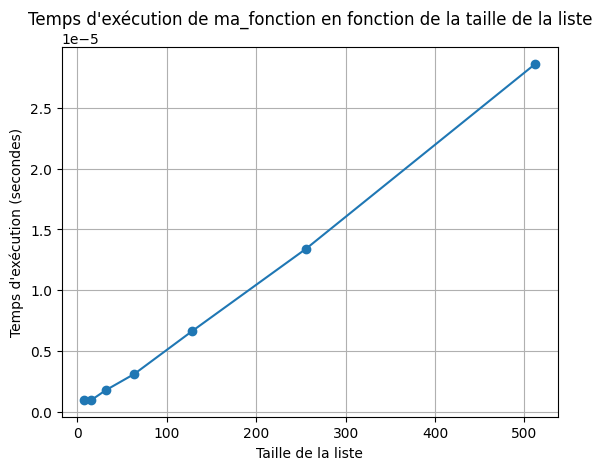

In [10]:
# EXEMPLE D'UILISATION DES MODULES TIMES ET MATPLOTLIB

import matplotlib.pyplot as plt
import time

def ma_fonction(L):
    resultat = []
    for i in range(len(L)):
        resultat.append(L[i] ** 2)
    return resultat

tailles = [2** i for i in range(3, 10)]
temps = []
nb_rep = 10

for taille in tailles:
    moy = 0
    for _ in range(nb_rep):
        L = list(range(taille))
        debut = time.perf_counter()
        ma_fonction(L)
        fin = time.perf_counter()
        moy += fin - debut
    temps.append(moy / nb_rep)

plt.plot(tailles, temps, marker='o')
plt.xlabel("Taille de la liste")
plt.ylabel("Temps d'exécution (secondes)")
plt.title("Temps d'exécution de ma_fonction en fonction de la taille de la liste")
plt.grid()
plt.show()
    

In [27]:
# FONCTIONS À COMPLÉTER

def algo_glouton(S, M):
    """
    Algorithme glouton sans nombre limité de pièces.

    Args:
    - S (list): Une liste d'entiers représentant les pièces triées par ordre décroissant
    - M (int): La somme à atteindre

    Returns:
    - tuple: (nb_pieces, pieces_utilisees) si succès OU None si échec
    """
    S_trie = sorted(S, reverse=True)
    pieces_utilisees = []
    nb_pieces = 0
    
    for piece in S_trie:
        # On calcule combien de fois on peut prendre la pièce courante
        quantite = M // piece
        
        if quantite > 0:
            nb_pieces += quantite
            # On ajoute 'quantite' fois la pièce dans notre liste
            pieces_utilisees += [piece] * quantite
            
            # On met à jour le montant restant
            M = M % piece 

    # Si le reste n'est pas nul à la fin, c'est un échec
    if M != 0:
        return None

    return nb_pieces, pieces_utilisees

def algo_prog_dyn(S, M):
    """
    Résout le problème du rendu de monnaie en utilisant la programmation dynamique et retourne à la fois le nombre minimum de pièces nécessaires et la liste des pièces utilisées.
    Args:
        S (list): Liste des pièces disponibles.
        M (int): Montant à atteindre.
    Returns:
        tuple: (Nombre minimum de pièces nécessaires pour atteindre le montant M, Liste des pièces utilisées), ou (None, []) si ce n'est pas possible.
    """
    # Initialisation de la matrice d'indices et de la matrice de suivi des pièces utilisées
    mat = [[0 if m == 0 else float('inf') for m in range(M + 1)] for i in range(len(S) + 1)]
    used = [[[] for m in range(M + 1)] for i in range(len(S) + 1)]
    # À la case used[i][m], on stocke la liste des pièces utilisées pour atteindre le montant m avec les i premières pièces.

    # Remplissage de la matrice d'indices et de la matrice de suivi des pièces utilisées
    for i in range(1, len(S) + 1):
        for m in range(1, M + 1):
            if m - S[i - 1] >= 0:
                if 1 + mat[i][m - S[i - 1]] < mat[i - 1][m]:
                    mat[i][m] = 1 + mat[i][m - S[i - 1]]
                    used[i][m] = used[i][m - S[i - 1]] + [S[i - 1]]
                else:
                    mat[i][m] = mat[i - 1][m]
                    used[i][m] = used[i - 1][m]
            else:
                mat[i][m] = mat[i - 1][m]
                used[i][m] = used[i - 1][m]

    result = mat[len(S)][M]
    pieces_used = used[len(S)][M]
    return (result, pieces_used) if result != float('inf') else None

def Monnaie_graphe(S: list, M: int) -> dict:
    """
    Génère un graphe représentant les combinaisons de pièces possibles pour atteindre un montant spécifié
    en utilisant un ensemble donné de valeurs de pièces.

    Args:
    - S (list): Une liste d'entiers représentant les valeurs disponibles des pièces.
    - M (int): Un entier spécifiant le montant cible à atteindre.

    Returns:
    - graph: Un graphe (représenté sous forme de dictionnaire)
    """
    file = [M]
    graph = {M: {}}              
    while file:
        M = file.pop(0)
        for piece in S: 
            if piece <= M:
                
                if M - piece in graph:
                    graph[M][M-piece] = piece

                else:
                    graph[M - piece] = {}
                    graph[M][M-piece] = piece               
                    file.append(M-piece)

        #if piece == M:      # on peut s'arrêter dès qu'on a ajouté le noeud 0
        #    break           # pas l'arbre complet mais contient le plus court chemin 

    
    return graph

def plus_court_chemin_backtracking(graph: dict, start: str) -> list:
    """
    Calcule les distances les plus courtes depuis un nœud de départ dans un graphe.

    Args:
    - graph (dict): Un dictionnaire représentant le graphe
    - start (str): Le nœud de départ à partir duquel calculer les distances.

    Returns:
    - list: le chemin utilisé et les montants intermédiaires
    """
    file = [start]
    parent = {}
    while file: 
        m = file.pop(0)

        for rem in graph[m]:
            if rem not in parent:
                parent[rem] = m 
                file.append(rem)

        if m == 0:
            break

    chemin = [0]
    while chemin[-1] != start:
        m = chemin[-1]
        chemin.append(parent[m])
    chemin.reverse()
    return chemin


def algo_exploration(S, M):
    graph = Monnaie_graphe(S, M)
    if 0 not in graph:
        return None  # montant inatteignable
    
    chemin = plus_court_chemin_backtracking(graph, M)
    # chemin = [M, ..., 0] : les montants intermédiaires
    # Les pièces utilisées = les arcs, soit les différences entre noeuds consécutifs
    T = [chemin[i] - chemin[i+1] for i in range(len(chemin) - 1)]
    return len(T), T


algorithmes = { 
    "Glouton": algo_glouton,
    "Programmation dynamique": algo_prog_dyn,
    "Exploration exhaustive": algo_exploration
}

In [28]:
# JEU DE DONNÉES À ADAPTER SI BESOIN

systemes = {
    "Euro canonique": [1, 2, 5, 10, 20, 50, 100, 200],
    "Non canonique 1": [1, 3, 4],
    "Non canonique 2": [1, 5, 7, 10]
}
 

montants = [100, 500, 1_000, 5_000, 10_000]


In [29]:
# FONCTION DE MESURE DE TEMPS

def mesurer_temps(fonction, S, M, nb_repetitions=5):
    """
    Mesure le temps moyen d'exécution de `fonction(S, M)`
    sur nb_repetitions exécutions.
    Retourne le temps moyen en secondes.
    """
    total = 0.0
    for _ in range(nb_repetitions):
        debut = time.perf_counter()
        fonction(S, M)
        fin = time.perf_counter()
        total += fin - debut
    return total / nb_repetitions


# Le test suivant doit afficher les temps d’exécution des différents algorithmes
print("Mesure des temps d'exécution des algorithmes...")
S = systemes["Euro canonique"]
M = 1_000
for nom, fonction in algorithmes.items():
    print(f"Algorithme : {nom}")
    t = mesurer_temps(fonction, S, M, nb_repetitions=10)
    print(f"Temps moyen pour M={M} : {t} secondes")


Mesure des temps d'exécution des algorithmes...
Algorithme : Glouton
Temps moyen pour M=1000 : 1.829999382607639e-06 secondes
Algorithme : Programmation dynamique
Temps moyen pour M=1000 : 0.007334550000086893 secondes
Algorithme : Exploration exhaustive
Temps moyen pour M=1000 : 0.001154709998809267 secondes


In [30]:
# BOUCLE DE MESURE DES TEMPS POUR TOUS LES ALGORITHMES ET SYSTÈMES

# Vous pouvez stocker les résultats dans une structure de données
# adaptée, par exemple un dictionnaire imbriqué. Voici un exemple :
resultats = {
    nom_algo: {nom_sys: [] for nom_sys in systemes}
    for nom_algo in algorithmes
}


NB_REP = 5

for nom_sys, S in systemes.items():
    print(f"Système : {nom_sys}")
    for M in montants:
        for nom_algo, fn in algorithmes.items():
            t = mesurer_temps(fn, S, M, nb_repetitions=NB_REP)
            resultats[nom_algo][nom_sys].append(t)
        print(f"M={M} : ok")

Système : Euro canonique
M=100 : ok
M=500 : ok
M=1000 : ok
M=5000 : ok
M=10000 : ok
Système : Non canonique 1
M=100 : ok
M=500 : ok
M=1000 : ok
M=5000 : ok
M=10000 : ok
Système : Non canonique 2
M=100 : ok
M=500 : ok
M=1000 : ok
M=5000 : ok
M=10000 : ok


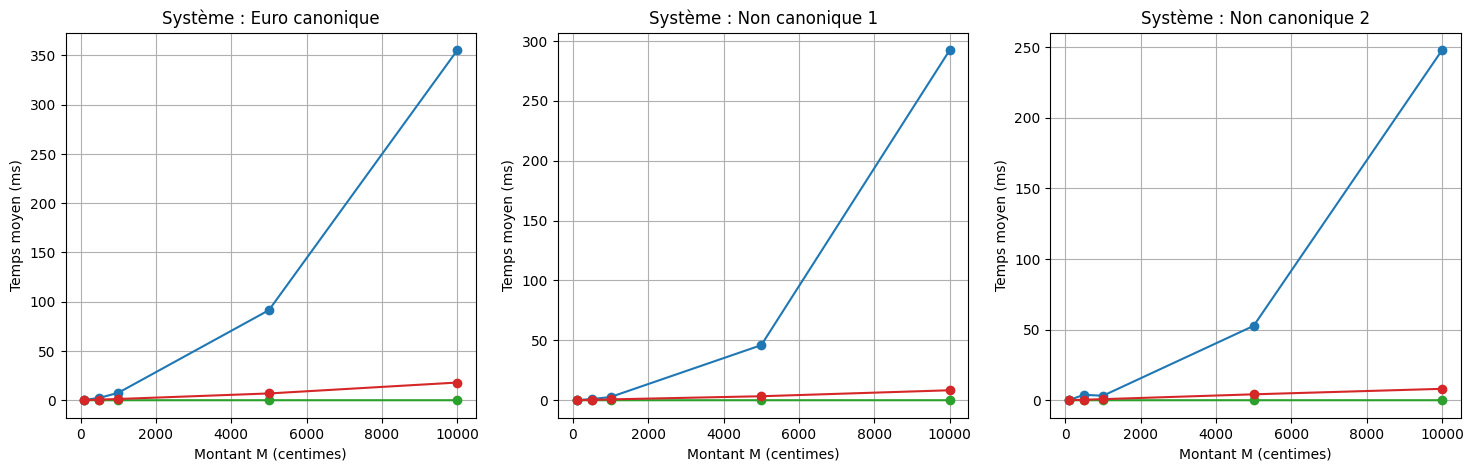

In [31]:
# TRACÉ DES COURBES

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(systemes), figsize=(6 * len(systemes), 5))

colors = {"Glouton": "tab:green", "Programmation dynamique": "tab:blue", "Exploration exhaustive": "tab:red"}

for ax, (nom_sys, _) in zip(axes, systemes.items()):
    for nom_algo in algorithmes:
        temps_algo = resultats[nom_algo][nom_sys]
        t_ms = [t * 1000 for t in temps_algo]
        ax.plot(montants, t_ms, label=nom_algo, color=colors[nom_algo], marker="o")
    ax.set_title(f"Système : {nom_sys}")
    ax.set_xlabel("Montant M (centimes)")
    ax.set_ylabel("Temps moyen (ms)")
    ax.grid(True)


plt.show()

Glouton en vert, Dynamique en bleu, Exploration en rouge.

In [32]:

# ESQUISSE DE MESURE DE LA MÉMOIRE (OPTIONNEL)

import tracemalloc

def mesurer_memoire(fonction, S: list[int], M: int) -> int:
    """
    Mesure la mémoire maximale utilisée (en octets) lors d'un appel à fonction(S, M).
    Utilise tracemalloc, les valeurs sont des ordres de grandeur.
    """
    tracemalloc.start()
    fonction(S, M)
    _, mem_max = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return mem_max


print("Mémoire utilisée (en Ko) pour M=5000, système Euro canonique :")
S = systemes["Euro canonique"]
M = 5_000

for nom, fn in algorithmes.items():
    mem = mesurer_memoire(fn, S, M)
    print(f"{nom} : {mem / 1024} Ko")

n = len(S)
tailles_matrice = [(M, n * (M + 1)) for M in montants]
print("\nTaille théorique de la matrice DP (n x M cellules) :")
for M_val, taille in tailles_matrice:
    print(f"M={M_val} => {taille} cellules  ({taille * 8 / 1024**2} Mo)")


Mémoire utilisée (en Ko) pour M=5000, système Euro canonique :
Glouton : 0.4609375 Ko
Programmation dynamique : 188386.5732421875 Ko
Exploration exhaustive : 3392.724609375 Ko

Taille théorique de la matrice DP (n x M cellules) :
M=100 => 808 cellules  (0.00616455078125 Mo)
M=500 => 4008 cellules  (0.03057861328125 Mo)
M=1000 => 8008 cellules  (0.06109619140625 Mo)
M=5000 => 40008 cellules  (0.30523681640625 Mo)
M=10000 => 80008 cellules  (0.61041259765625 Mo)


In [33]:
# COMPARATIF DES ALGORITHMES SUR DES DONNEES EXTREMES

print("1. Cas où le glouton est sous-optimal (système non canonique)")

S_nc = [1, 3, 4] # Système non canonique
for M_test in [6, 9, 12]:
    res_g = algo_glouton(S_nc, M_test)
    res_dyn = algo_prog_dyn(S_nc, M_test)
    optimal = (res_g[0] == res_dyn[0]) if res_g is not None and res_dyn is not None else False
    print(f"S={S_nc}, M={M_test}, Glouton: {res_g[0]} pièces {res_g[1]}, Dynamique : {res_dyn[0]} pièces {res_dyn[1]} : {'Optimal' if optimal else 'glouton sous-optimal'}")

print("2. Système canonique : test de rapidité (pour M grand)")
S_euro = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
for M_test in [10_000, 20_000]:
    t_g  = mesurer_temps(algo_glouton, S_euro, M_test, 5)
    t_dyn = mesurer_temps(algo_prog_dyn, S_euro, M_test, 5)
    print(f"M={M_test}, Glouton: {t_g} s, Dynamique: {t_dyn} s, Dynamique/Glouton: dynamique est {t_dyn/t_g} fois plus lent")

1. Cas où le glouton est sous-optimal (système non canonique)
S=[1, 3, 4], M=6, Glouton: 3 pièces [4, 1, 1], Dynamique : 2 pièces [3, 3] : glouton sous-optimal
S=[1, 3, 4], M=9, Glouton: 3 pièces [4, 4, 1], Dynamique : 3 pièces [3, 3, 3] : Optimal
S=[1, 3, 4], M=12, Glouton: 3 pièces [4, 4, 4], Dynamique : 3 pièces [4, 4, 4] : Optimal
2. Système canonique : test de rapidité (pour M grand)
M=10000, Glouton: 1.4399993233382702e-06 s, Dynamique: 0.4000304800021695 s, Dynamique/Glouton: dynamique est 277799.07498484175 fois plus lent
M=20000, Glouton: 2.400000812485814e-06 s, Dynamique: 2.255088700001943 s, Dynamique/Glouton: dynamique est 939619.9735725182 fois plus lent


**Question 4.3 — Synthèse de vos résultats expérimentaux**


Expliquez ici, en quelques paragraphes, ce que montrent vos expériences :

- Dans quels cas les algorithmes gloutons sont-ils rapides et suffisants ?  
  Dans quels cas échouent-ils à trouver une solution optimale ?
- Comment se comportent les algorithmes d’exploration d’arbre lorsque $M$ grandit ?
- Les algorithmes de programmation dynamique confirment-ils bien les complexités
  théoriques annoncées ?
- Donnez au moins un exemple concret (système de pièces + montant $M$) pour illustrer
  un **choix « raisonné »** d’algorithme en fonction du compromis temps / mémoire / qualité
  de la solution.

Votre réponse doit s’appuyer sur **les courbes / mesures générées par votre code Python**
dans la cellule précédente.


---

### Algorithme glouton

Le glouton est de loin le plus rapide : son temps d'exécution est **O(n)**, indépendant du montant M. Il est **suffisant et optimal** sur le système euro canonique.

En revanche, sur les systèmes non canoniques comme {1, 3, 4}, le glouton échoue à trouver la solution optimale : pour M=6, il rend 4+1+1 = 3 pièces alors que 3+3 = 2 pièces suffit.


### Algorithme d'exploration

L'exploration construit le graphe des montants accessibles, puis remonte le chemin le plus court. Sa complexité est exponentielle dans le pire des cas, mais elle reste bien plus rapide que la dynamique. La dynamique est ralentie par le fait qu'elle doit obligatoirement remplir l'intégralité d'une matrice $n \times M$.

### Algorithme de Programmation Dynamique

Pour M grand, d'après les courbes, la complexité semble être linéaire comme attendu (O(n.M)), mais le temps d'exécution reste bien supérieur à celui des 2 autres méthodes, car on doit calculer chaque case de la matrice.


### Exemple de choix d'algorithme


- Système canonique, M quelconque : Glouton - Optimal, temps en O(n), mémoire O(n)
- Système non canonique, petit M (< 10 000) : Dynamique - Optimal, temps raisonnable

**Exemple concret :** pour S={1,3,4} et M=6 :
- le glouton retourne T=[2,0,1] => 4+1+1 = 3 pièces (sous-optimal) ;
- l'exploration et la prog dynamique donnent toutes les deux 3+3 = 2 pièces (optimal).
